Adjusting the font of the output particularly in Google Colab

In [ ]:
from IPython.display import HTML
shell = get_ipython()

def adjust_font_size():
  display(HTML('''<style>
    body {
      font-size: 16px;
    }
  '''))

if adjust_font_size not in shell.events.callbacks['pre_execute']:
  shell.events.register('pre_execute', adjust_font_size)

 Mounting my google drive within Colab


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Changing the directory to my projects folder

In [ ]:
os.chdir("drive/MyDrive/Colab ""Notebooks/Project/ProjectNYCEnsemble")
# os.chdir("ProjectNYCEnsemble")


Print the current working directory

In [ ]:
os.getcwd()

'/content/drive/MyDrive/Colab Notebooks/Project/ProjectNYCEnsemble'

Importing the necessary libraries

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pandas.api.types import is_numeric_dtype
# ! pip install plotly
import plotly.express as px

Graphing Libraries

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import pyproj
from functools import partial
from shapely.geometry import box
from shapely.ops import transform
import fiona
import shapefile as shp

Libraries imported for building a model on this later on (not needed for EDA)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb


Setting the Seaborn Style for plotting visualizations

In [ ]:
sns.set(style='whitegrid', palette='pastel', color_codes=True)
sns.mpl.rc('figure', figsize=(10,6))

#### Unzip the input file and read using the read_csv function of pandas

In [ ]:
!unzip -q "/content/drive/MyDrive/Colab Notebooks/Project/ProjectNYCEnsemble/ProjectNYCEnsemble.zip"


[/content/drive/MyDrive/Colab Notebooks/Project/ProjectNYCEnsemble/ProjectNYCEnsemble.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/drive/MyDrive/Colab Notebooks/Project/ProjectNYCEnsemble/ProjectNYCEnsemble.zip or
        /content/drive/MyDrive/Colab Notebooks/Project/ProjectNYCEnsemble/ProjectNYCEnsemble.zip.zip, and cannot find /content/drive/MyDrive/Colab Notebooks/Project/ProjectNYCEnsemble/ProjectNYCEnsemble.zip.ZIP, period.


In [ ]:
nyc_data_presplitting = pd.read_csv('../../Datasets/nyc_taxi_trip_duration.csv')

In [ ]:
nyc_data_presplitting.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [ ]:
print("Rows:{:,d}".format(nyc_data_presplitting.shape[0]), "Cols:{:,d}".format(nyc_data_presplitting.shape[1]))

Rows:729,322 Cols:11


In [ ]:
X_train, X_test, y_train, y_test=train_test_split(nyc_data_presplitting.drop(columns='trip_duration'),nyc_data_presplitting['trip_duration'],test_size=0.3)

### Save only the training split done in a dataframe named nyc_data for EDA purpose. We avoid taking a peek into the test set on which we will test out model starightaway.

In [ ]:
nyc_data=pd.concat([X_train, y_train], axis=1)

### Step 1:- As the data is now loaded, let's begin exploring by inspecting  a few rows to get a basic understanding of the data

In [ ]:
nyc_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
54357,id2817321,2,2016-05-17 17:27:46,2016-05-17 18:16:31,2,-73.957451,40.779881,-73.986237,40.743408,N,2925
253091,id0531999,2,2016-01-27 18:52:05,2016-01-27 19:05:55,1,-73.974136,40.763355,-73.965820,40.764572,N,830
720605,id1644502,2,2016-02-28 00:03:49,2016-02-28 00:13:15,1,-74.008072,40.740200,-73.991127,40.734982,N,566
39546,id2252603,2,2016-05-03 21:25:31,2016-05-03 21:35:08,2,-73.991402,40.745026,-73.972435,40.755661,N,577
191987,id2368188,1,2016-05-02 08:42:58,2016-05-02 08:54:39,1,-73.980469,40.764896,-73.984863,40.747894,N,701



####  Display the dimensions (row, column) of the dataset


#### Take a look at the columns of NYC Data

In [ ]:
nyc_data.columns


Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

### Inspect the datatypes


In [ ]:
nyc_data.dtypes

id                     object
vendor_id               int64
pickup_datetime        object
dropoff_datetime       object
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag     object
trip_duration           int64
dtype: object

### Step2:- Before we explore the dataset further, let's convert the pick up & drop off datetime fields to datetime variables as they are of type object (or are considered categories at the moment)

In [ ]:
nyc_data['pickup_datetime']=pd.to_datetime(nyc_data['pickup_datetime'])
nyc_data['dropoff_datetime']=pd.to_datetime(nyc_data['dropoff_datetime'])

### Lets inspect the dimensions a bit further - let's see how many categorical,  numerical  fields exist,


In [ ]:
nyc_data.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [ ]:
nyc_data.iloc[1,:]

id                              id0531999
vendor_id                               2
pickup_datetime       2016-01-27 18:52:05
dropoff_datetime      2016-01-27 19:05:55
passenger_count                         1
pickup_longitude               -73.974136
pickup_latitude                 40.763355
dropoff_longitude               -73.96582
dropoff_latitude                40.764572
store_and_fwd_flag                      N
trip_duration                         830
Name: 253091, dtype: object

In [ ]:
categorical_columns=[col for col in nyc_data.columns if (nyc_data[col].dtypes=='O' ) ]
print("There are {}".format(len(categorical_columns)),"categorical variables")
categorical_columns

There are 2 categorical variables


['id', 'store_and_fwd_flag']

In [ ]:
numeric_columns=[col for col in nyc_data.columns if (is_numeric_dtype(nyc_data[col] ) )]
print("There are {}".format(len(numeric_columns)),"numerical variables")

There are 7 numerical variables


In [ ]:
numeric_columns

['vendor_id',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'trip_duration']

In [ ]:
discrete_columns=[col for col in numeric_columns if ((nyc_data[col].nunique()<10) and (col!='trip_duration' ))]
print("There are {}".format(len(discrete_columns))+ " discrete variables")
discrete_columns

There are 2 discrete variables


['vendor_id', 'passenger_count']

In [ ]:
target_column=[col for col in numeric_columns if (col=='trip_duration')]
continuous_columns=set(numeric_columns).difference(discrete_columns).difference(target_column)
print("There are {}".format(len(continuous_columns))+ " continuous variables")
continuous_columns

There are 4 continuous variables


{'dropoff_latitude',
 'dropoff_longitude',
 'pickup_latitude',
 'pickup_longitude'}

###  So  we can see the id field appears to be a unique identifier for each trip.

In [ ]:
print("The number of distinct unique trips : {}".format(nyc_data['id'].nunique()))

NameError: name 'nyc_data' is not defined

### Let's attempt to see the extent of cardinality in these categorical variables. Store and Forward is a boolean (1/0) stored as a Y/N flag to indicate whether a record of the trip was stored in the vehicle memory before sending it over to the vendor

In [ ]:
for col in categorical_columns:
   print(col,":{}".format(tuple(nyc_data[col].unique()[0:10])))

id :('id2817321', 'id0531999', 'id1644502', 'id2252603', 'id2368188', 'id0237885', 'id3733447', 'id1831589', 'id1910862', 'id0669196')
store_and_fwd_flag :('N', 'Y')


### We may now convert it to a numeric(1/0) variable from the current categorical (Y/N) to feed into the model later on

In [ ]:
nyc_data['store_and_fwd_flag']=nyc_data['store_and_fwd_flag'].map({'Y':1,'N':0})

### Look for Missing Values - There are no missing values seen.

In [ ]:
nyc_data.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

## Let's do some univariate and bivariate analysis and do the necessary data manipulations as we go along the way

 1. We begin looking at the count or frequency plots for the categorical & discrete variables

 2. Later we explore the datetime variable and extract features from it on which we again do some count plots to understand how the trips are themselves distributed among these variable categories.

 3. From univariate , we also later delve into bivariate analysis where we analyse relationship with the target variable

 4. We look at the lat and long variables to explore visually where the trips are

 5. While visualizing, we also actively look for & remove outliers that can skew/influence the analysis and  also hinder visualizing them graphically


### Passenger & vendor Id count Plots:
#### Observations:-
    Passenger Count:-

      > 70% of the data has just 1 passenger. The max passenger count is 6 which indicates that it must be a bigger vehicle that allow that kind of seating capacity
      > 14% had 2 or more.
      > Only about 15% had 3 or more passengers
    Vendor Id
      > Data is somewhat equally split between the vendors 1 & 2

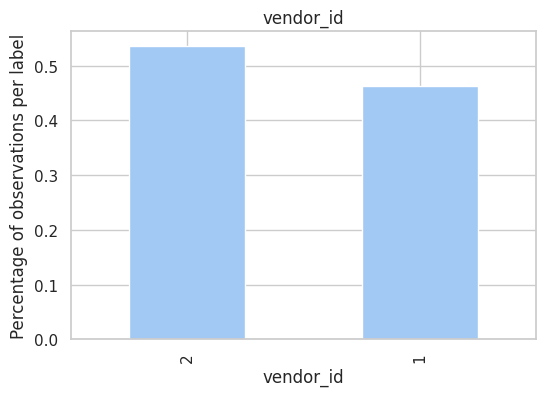

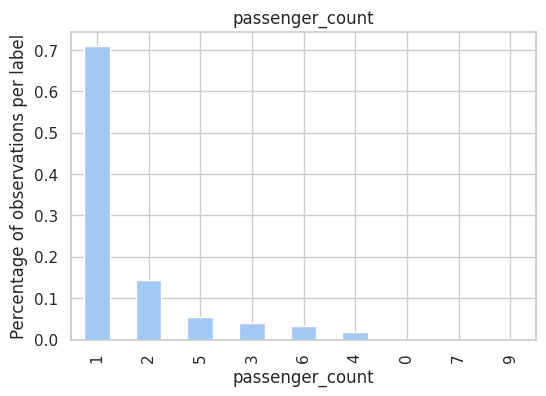

In [ ]:

for var in discrete_columns:

    plt.figure(figsize=(6,4))
    (nyc_data[var].value_counts(normalize=True)).plot.bar()
    plt.ylabel('Percentage of observations per label')
    plt.title(var)
    plt.show()

Text(0, 0.5, 'Frequency')

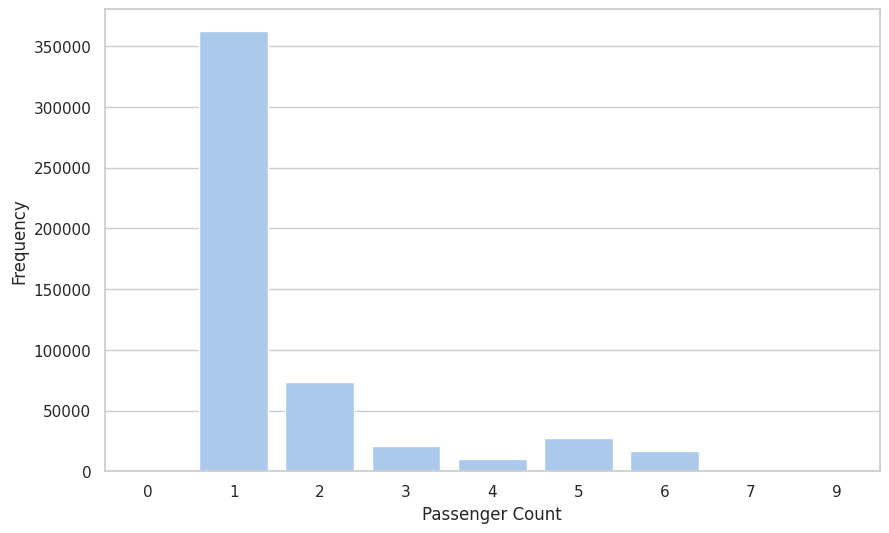

In [ ]:
# sns.countplot(nyc_data['passenger_count'])

sns.countplot(data=nyc_data, x='passenger_count')
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')

In [ ]:
categorical_columns

['id', 'store_and_fwd_flag']

Text(0, 0.5, 'Frequency')

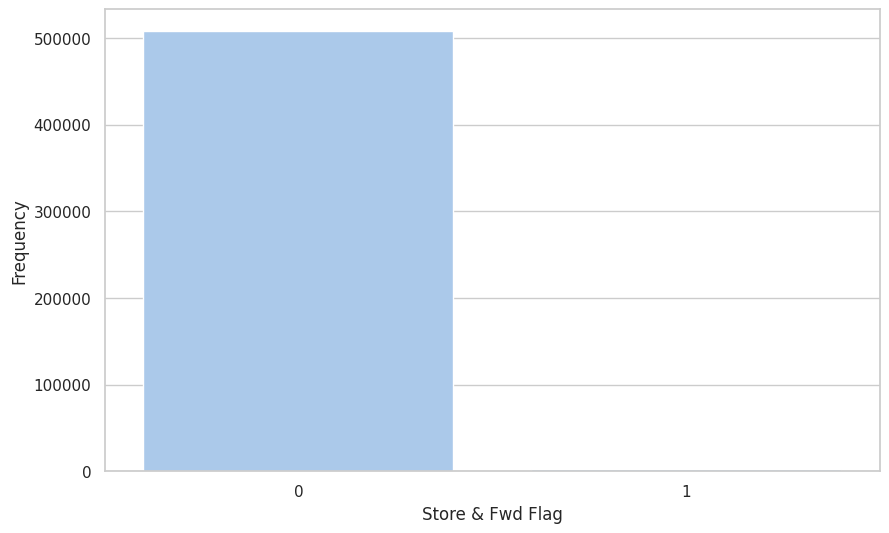

In [ ]:
sns.countplot(nyc_data, x="store_and_fwd_flag")
plt.xlabel('Store & Fwd Flag')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

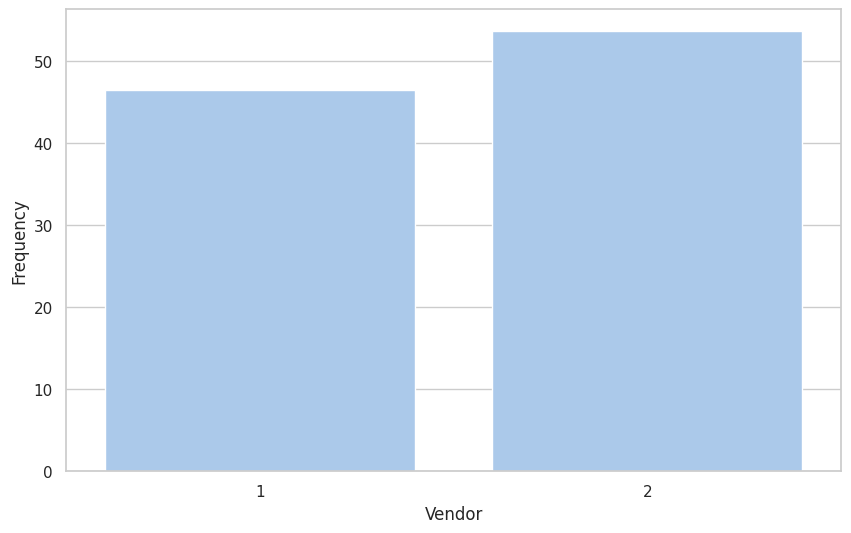

In [ ]:
sns.countplot(nyc_data, x="vendor_id", stat='percent')
plt.xlabel('Vendor')
plt.ylabel('Frequency')

### The pickup_datetime & dropoff_datetime are seen to be of the categorical i.e. of the object data type . Let's change them to datetime fields using pandas to_datetime method

### Let's explore what the date range for the data looks like -  Looks like we have 6 months worth of data

In [ ]:
print("Earliest pick up time seen {}".format(nyc_data['pickup_datetime'].dt.date.min()))

print("Latest pick up time seen {}".format(nyc_data['pickup_datetime'].dt.date.max()))

Earliest pick up time seen 2016-01-01
Latest pick up time seen 2016-06-30


In [ ]:
print("Earliest Drop off time seen {}".format(nyc_data['dropoff_datetime'].dt.date.min()))

print("Latest Drop off time seen {}".format(nyc_data['dropoff_datetime'].dt.date.max()))



Earliest Drop off time seen 2016-01-01
Latest Drop off time seen 2016-07-01


### Since we already have the pickup and the dropoff datetime fields, trip duration can merely be derived from these. However, as we have the trip_duration as a separate data field, let's validate to see if the difference between dropoff_datetime & the pickup_datetime is equal to the trip_duration.




In [ ]:
((nyc_data['dropoff_datetime']-nyc_data['pickup_datetime'])/np.timedelta64(1,'s')==nyc_data['trip_duration']).value_counts()


True    510525
Name: count, dtype: int64

### So the check above shows that it is indeed equal

### The below method i.e. describe when used , reveals that the trip duration is spread over a very large range of values . Median being 663 secs, min being 1 sec (quite strange, more likely a data capture error !) , max being close to 2mn secs.

In [ ]:
(nyc_data['trip_duration']).describe()

count    5.105250e+05
mean     9.555340e+02
std      4.165042e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.630000e+02
75%      1.075000e+03
max      1.939736e+06
Name: trip_duration, dtype: float64

In [ ]:
nyc_data.shape[0]

510525

In [ ]:
max_trip_duration=nyc_data['trip_duration'].max()/(3600*24)
min_trip_duration=nyc_data['trip_duration'].min()

### Both of the below appear to be outliers with the shortest trip lasting only a sec and the longest being 22 days.

In [ ]:
print("The longest trip lasted {:.1f} days".format(max_trip_duration))
print("The shortest trip lasted {:.1f} sec".format(min_trip_duration))

The longest trip lasted 22.5 days
The shortest trip lasted 1.0 sec


There are 10 outlier trips where the shortest trip lasted only a sec. These are clearly outlier points that may be approximated based on other closely related latitude longitude combinations. Else one can also safely remove them as they are only 13 points of the 729K records

In [ ]:
nyc_data[nyc_data.trip_duration==1].shape[0]

8

In [ ]:
nyc_data[nyc_data.trip_duration==nyc_data['trip_duration'].max()]
print("The above is the one that lasted 22 days - also an outlier")

The above is the one that lasted 22 days - also an outlier


So let's proceed to remove them

In [ ]:
max_trip=nyc_data['trip_duration'].max()
min_trip=nyc_data['trip_duration'].min()

In [ ]:
nyc_data=nyc_data[(~(nyc_data.trip_duration==nyc_data['trip_duration'].max()) & ~(nyc_data.trip_duration==nyc_data['trip_duration'].min))]

### 50% of the trips were about 11 minutes of less

In [ ]:
(nyc_data['trip_duration']/60).describe()

count    510524.000000
mean         15.862274
std          52.664582
min           0.016667
25%           6.616667
50%          11.050000
75%          17.916667
max        1439.850000
Name: trip_duration, dtype: float64

In [ ]:
nyc_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
54357,id2817321,2,2016-05-17 17:27:46,2016-05-17 18:16:31,2,-73.957451,40.779881,-73.986237,40.743408,0,2925
253091,id0531999,2,2016-01-27 18:52:05,2016-01-27 19:05:55,1,-73.974136,40.763355,-73.965820,40.764572,0,830
720605,id1644502,2,2016-02-28 00:03:49,2016-02-28 00:13:15,1,-74.008072,40.740200,-73.991127,40.734982,0,566
39546,id2252603,2,2016-05-03 21:25:31,2016-05-03 21:35:08,2,-73.991402,40.745026,-73.972435,40.755661,0,577
191987,id2368188,1,2016-05-02 08:42:58,2016-05-02 08:54:39,1,-73.980469,40.764896,-73.984863,40.747894,0,701


<Axes: ylabel='trip_duration'>

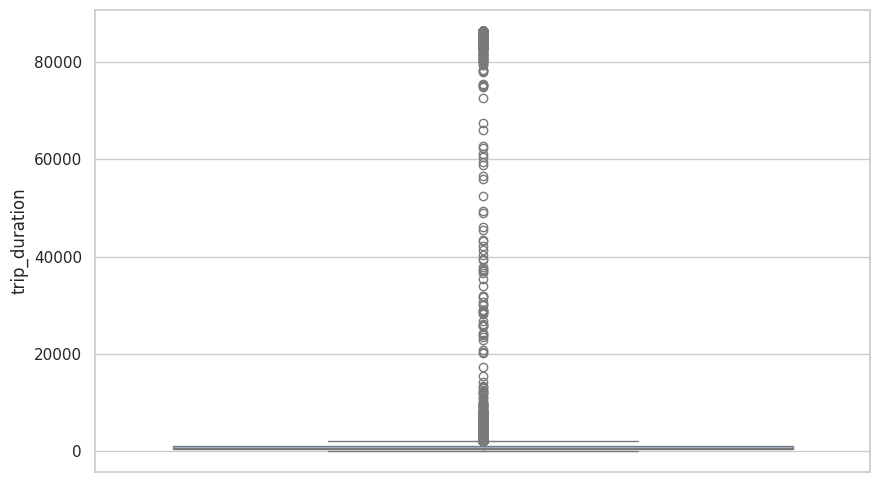

In [ ]:
sns.boxplot(nyc_data['trip_duration'])

### The results of the describe method as well as the boxplot both indicate the distribution is spread over a very large range of values. To understand the distibution better, let's shrink them down to a log scale. This will also compress the range of values thereby minimizing the effect of outliers on rest of the data.

In [ ]:
nyc_data['log_trip_duration']=np.log(nyc_data['trip_duration'].values+1) # +1 to avoid passing a negative log for which the log would be undefined

### This is further illustrated by the boxplot below. So as can be seen there are outliers in there that are likely to skew rest of the data. Hence we need to scale down these values so that the resulting range is more easy to visualize and work with. One could also look closely into these outlier values to determine if they are an erroneous entry and need to be imputed (using mean/median) or need any capping or even removed to avoid these points influencing the analysis .

<Axes: ylabel='log_trip_duration'>

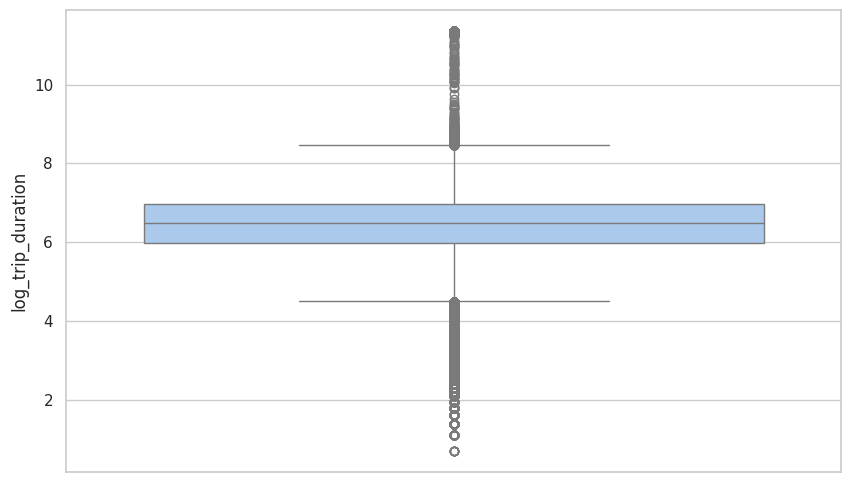

In [ ]:
sns.boxplot(nyc_data['log_trip_duration'])

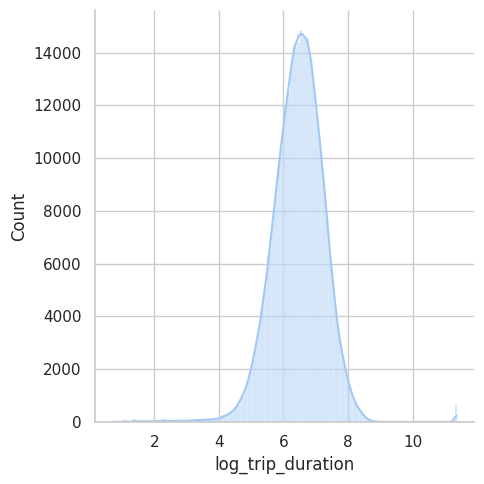

In [ ]:
sns.displot(nyc_data['log_trip_duration'], kde=True, bins=200)

### Deriving features from the pickup datetime variable :- day of the week, month, hour .

In [ ]:
nyc_data['WeekDay']=nyc_data['pickup_datetime'].dt.weekday
# 0 - Monday
nyc_data['Month']=nyc_data['pickup_datetime'].dt.month
nyc_data['hour']=nyc_data['pickup_datetime'].dt.hour
nyc_data['pickup_date']=nyc_data['pickup_datetime'].dt.date

In [ ]:
nyc_data.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'log_trip_duration', 'WeekDay', 'Month', 'hour',
       'pickup_date'],
      dtype='object')

In [ ]:
# nyc_data['Mean_trip_by_Weekday']=nyc_data.groupby(nyc_data['WeekDay'])['trip_duration'].transform('mean')

### Frequency Plot - to see how many trips we had on each day of the week

<Axes: xlabel='WeekDay'>

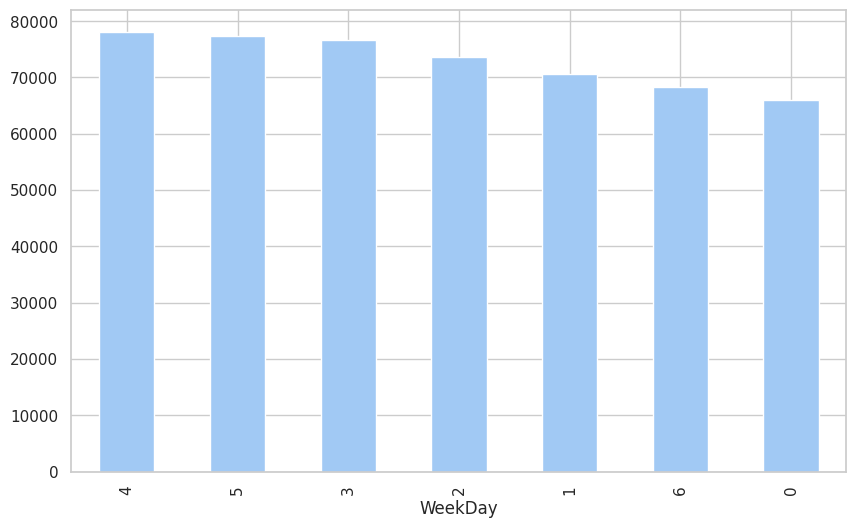

In [ ]:
nyc_data['WeekDay'].value_counts().plot.bar()

In [ ]:
nyc_data['Weekday_cat']=nyc_data['WeekDay'].map({0:'Monday',1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6: 'Sunday'})

### The least number of rides are on Sundays and Mondays. Most rides are seen on Thursday, Friday and Saturday. . This is in terms of the number of rides however.

<Axes: xlabel='Weekday_cat'>

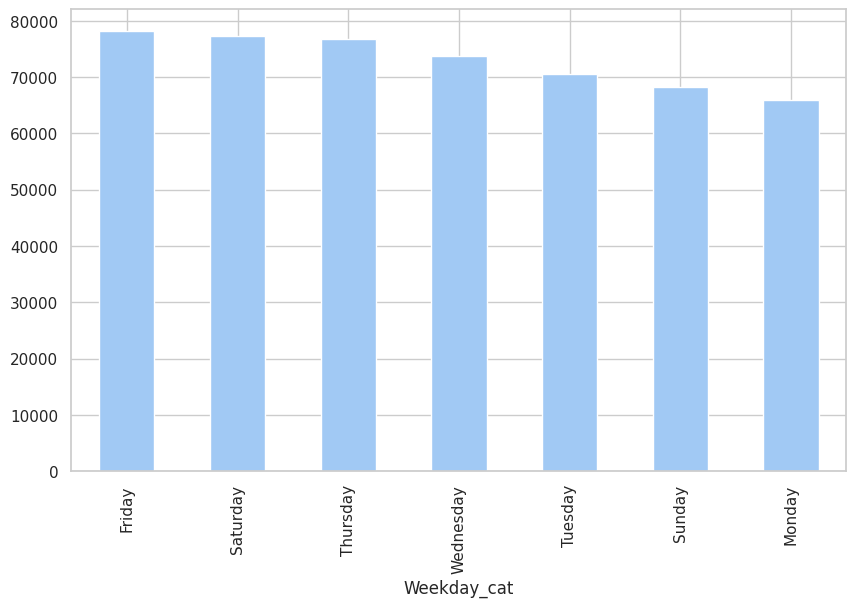

In [ ]:
nyc_data['Weekday_cat'].value_counts().plot.bar()

## Some hours of the day are clearly busier than the hours. Rides peak in the  evening hours beginning 6pm -7 pm . Least number of rides are seen in the early morning hours of 3am, 4am & 5am

<Axes: xlabel='hour'>

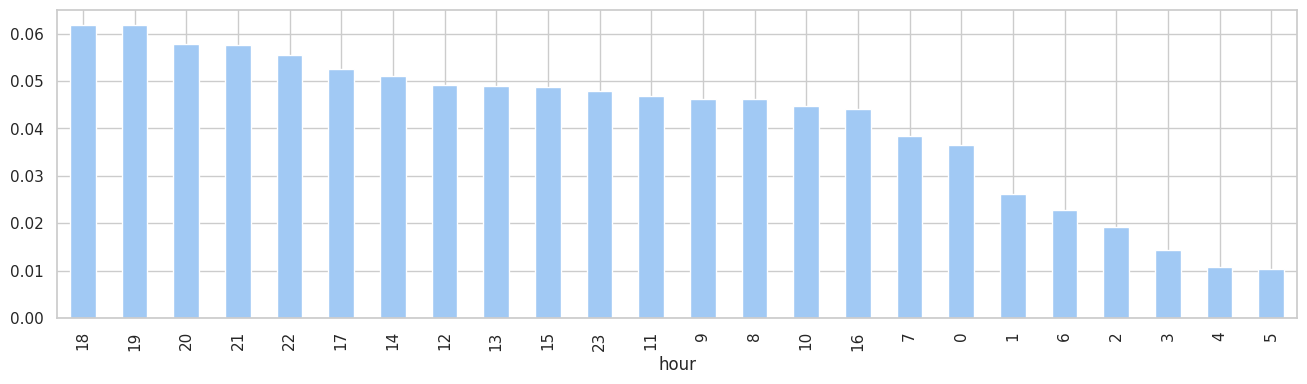

In [ ]:
plt.figure(figsize=(16,4))

# nyc_data['hour'].value_counts().plot.bar()
nyc_data['hour'].value_counts(normalize=True).plot.bar()

Looks like on Sunday and Monday there are both fewer trips and trips of shorter duration as seen from the below. On the contrary, Thursdays which is also one of the busy days in the week sees trips of longer duration. Some of the other longer trips are seen on Fridays and Wednesdays

In [ ]:
nyc_data.groupby(nyc_data['Weekday_cat'])['trip_duration'].apply(lambda x: x.mean())

Weekday_cat
Friday        982.344446
Monday        902.651215
Saturday      918.627661
Sunday        894.403538
Thursday     1010.257346
Tuesday       964.260652
Wednesday     978.134346
Name: trip_duration, dtype: float64

In [ ]:
nyc_data.groupby(nyc_data['hour'])['trip_duration'].apply(lambda x: x.mean())

hour
0      895.493300
1      918.136855
2      841.844838
3      951.063010
4      947.575200
5      811.496699
6      707.530523
7      803.422531
8      939.460719
9      920.052667
10     947.620366
11     960.450406
12     979.076568
13    1023.141664
14    1086.871883
15    1099.042551
16    1118.114640
17    1049.000149
18     992.017330
19     877.925715
20     858.926066
21     897.472994
22     953.375810
23     924.914008
Name: trip_duration, dtype: float64

In [ ]:
# nyc_data['Mean_trip_by_Weekday']

In [ ]:
nyc_data.groupby('Weekday_cat')['trip_duration'].mean().reset_index()

,Weekday_cat,trip_duration
0,Friday,982.344446
1,Monday,902.651215
2,Saturday,918.627661
3,Sunday,894.403538
4,Thursday,1010.257346
5,Tuesday,964.260652
6,Wednesday,978.134346


### Thursday through Friday have trips of longer duration.

In [ ]:
df=nyc_data[['Weekday_cat','trip_duration']].groupby(['Weekday_cat']).mean().reset_index()
fig = px.bar( data_frame=df, x='Weekday_cat',y='trip_duration', width=800, height=600)
fig.show()

Frequency plots indicate that early morning hours are the least busy mainly 3AM to 5AM . The trips during this duration lasted a little over 900s

Some of the busiest hours such as 6PM, 7PM has multiple trips of very shorter durations too, meaning the trips were of shorter duration , so more trips could be done in those busy hours too.

Between 1pm to 4pm were when trips were of the longest duration.

The hour of the day and day of the week if looked at in conjunction may also have some valuable insight to offer to understand if there are variations in hourly patterns depending on what day of the week it is. This info may help better model the data.

<Axes: xlabel='hour'>

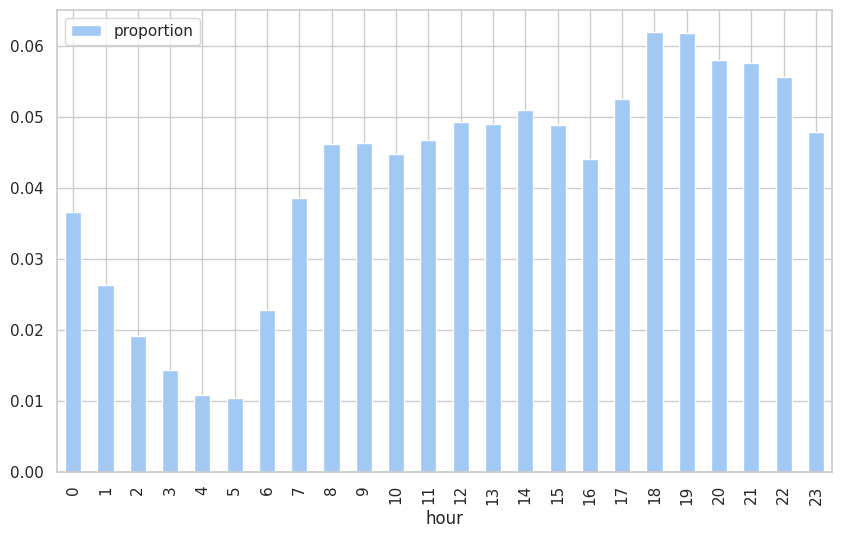

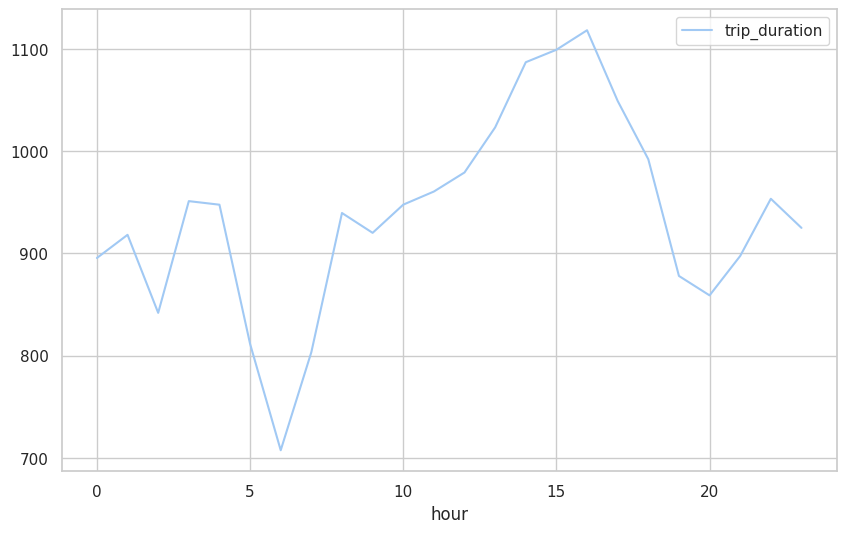

In [ ]:
# fig,ax=plt.subplots()
pd.DataFrame(nyc_data['hour'].value_counts(normalize=True)).sort_values( by='hour', ascending=True).plot.bar()

nyc_data[['hour','trip_duration']].groupby(['hour']).mean().plot.line()

In [ ]:
df=nyc_data[['Weekday_cat','hour','id']].drop_duplicates()
no_of_trips=df[['Weekday_cat','hour']].value_counts(normalize=False).reset_index()
mean_duration=nyc_data.groupby(['Weekday_cat','hour']).agg({'trip_duration':'mean'}).reset_index()

In [ ]:
no_of_trips.head()

,Weekday_cat,hour,count
0,Friday,19,4960
1,Thursday,21,4938
2,Thursday,19,4928
3,Thursday,18,4776
4,Thursday,22,4754


The line plots for Saturday and Sunday are similar. They have more trips seen in the early morning hours. Also early morning hours are more or less as busy as the evening hours on weekends. However comparing the line plot and frequency plot of Sat,  Sun against weekdays indicates that peak evening hours are not as busy on weekends. Sunday however is the least busy day as one would expect. Tuesdays through Fridays are very busy with trips of longest durations seen on a Thursday

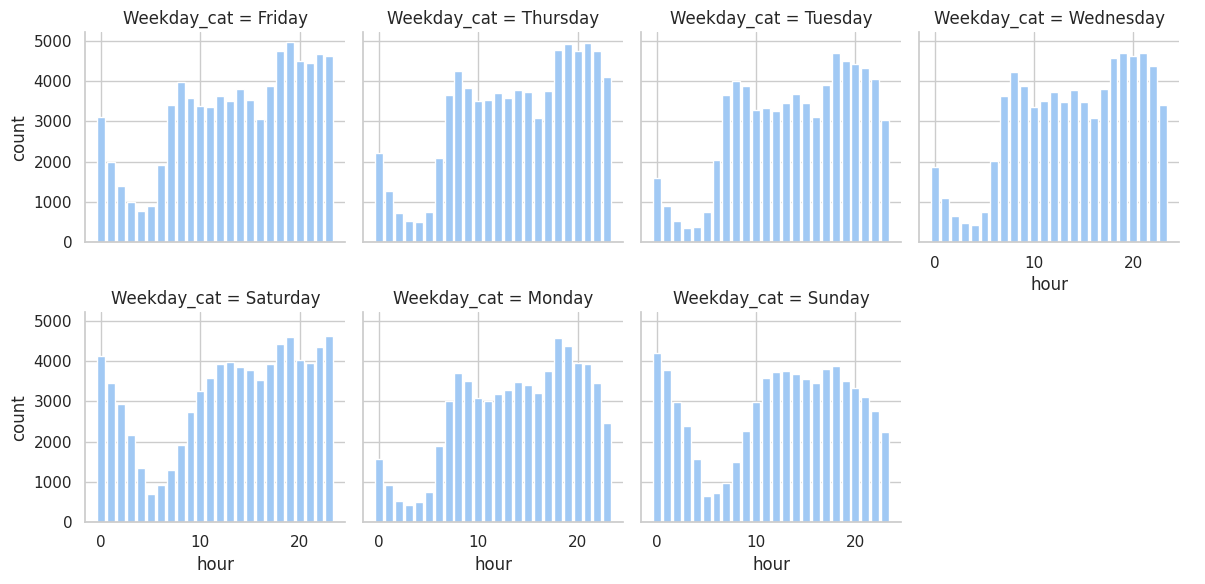

In [ ]:
graph=sns.FacetGrid(no_of_trips, col='Weekday_cat', col_wrap=4)
graph.map(plt.bar, "hour",'count' ).add_legend()
# show the object
plt.show()

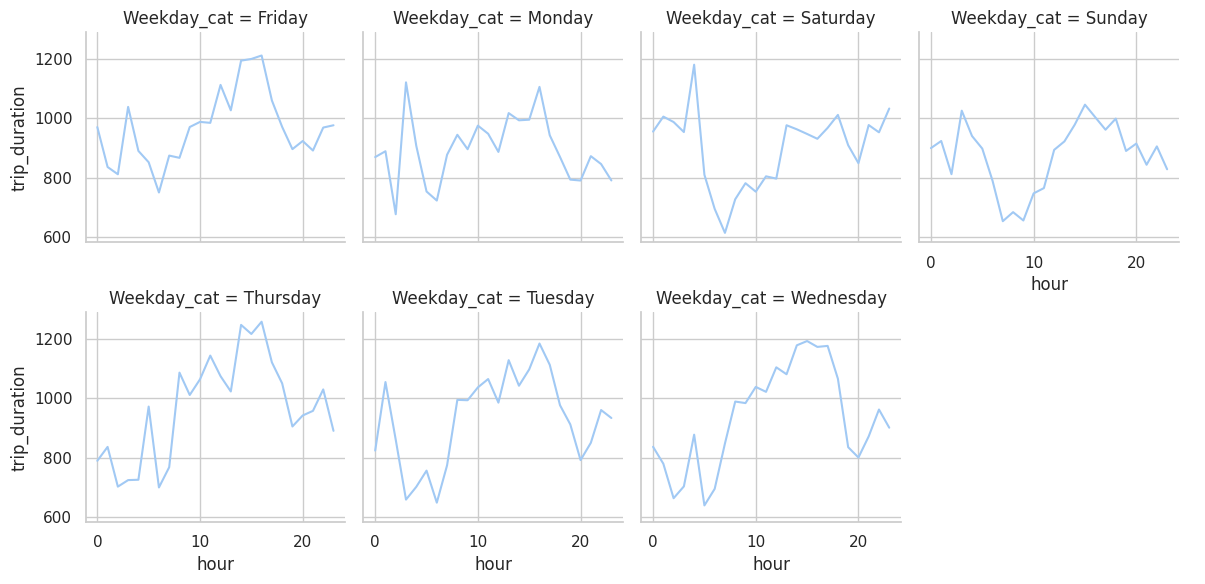

In [ ]:
graph=sns.FacetGrid(mean_duration, col='Weekday_cat', col_wrap=4)
graph.map(sns.lineplot, 'hour','trip_duration').add_legend()
plt.show()

In [ ]:
# df=nyc_data[['pickup_date','trip_duration']].groupby(['pickup_date']).mean().reset_index()
# fig = px.line( data_frame=df, x='pickup_date',y='trip_duration', width=1500, height=600, markers=True )
# fig.update_traces(marker=dict(color='purple',size=9) ,line=dict(
#         color='darkgray',
#         width=4))
# fig.show()

In [ ]:
nyc_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,log_trip_duration,WeekDay,Month,hour,pickup_date,Weekday_cat
54357,id2817321,2,2016-05-17 17:27:46,2016-05-17 18:16:31,2,-73.957451,40.779881,-73.986237,40.743408,0,2925,7.981392,1,5,17,2016-05-17,Tuesday
253091,id0531999,2,2016-01-27 18:52:05,2016-01-27 19:05:55,1,-73.974136,40.763355,-73.965820,40.764572,0,830,6.722630,2,1,18,2016-01-27,Wednesday
720605,id1644502,2,2016-02-28 00:03:49,2016-02-28 00:13:15,1,-74.008072,40.740200,-73.991127,40.734982,0,566,6.340359,6,2,0,2016-02-28,Sunday
39546,id2252603,2,2016-05-03 21:25:31,2016-05-03 21:35:08,2,-73.991402,40.745026,-73.972435,40.755661,0,577,6.359574,1,5,21,2016-05-03,Tuesday
191987,id2368188,1,2016-05-02 08:42:58,2016-05-02 08:54:39,1,-73.980469,40.764896,-73.984863,40.747894,0,701,6.553933,0,5,8,2016-05-02,Monday


In [ ]:
nyc_data.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'log_trip_duration', 'WeekDay', 'Month', 'hour',
       'pickup_date', 'Weekday_cat'],
      dtype='object')

In [ ]:
nyc_pickup_data=nyc_data[['pickup_longitude','pickup_latitude']]
nyc_dropoff_data=nyc_data[['dropoff_longitude','dropoff_latitude']]

Some of these values are clearly outliers - these when plotted do not even end up in land masses. Some of these outlier points for the pickup co-ordinates are located in the Ocean. We may cap the outliers to the bounds of NYC co-ordinates or even based on the distribution up to a standard deviation as an example.

In [ ]:
nyc_pickup_data.describe()

,pickup_longitude,pickup_latitude
count,510524.000000,510524.000000
mean,-73.973564,40.750896
std,0.078473,0.031605
min,-121.933342,34.712234
25%,-73.991859,40.737331
50%,-73.981750,40.754082
75%,-73.967331,40.768295
max,-70.511902,43.486885


In [ ]:
nyc_dropoff_data.describe()

,dropoff_longitude,dropoff_latitude
count,510524.000000,510524.000000
mean,-73.973461,40.751769
std,0.078147,0.036879
min,-121.933304,32.181141
25%,-73.991310,40.735935
50%,-73.979736,40.754509
75%,-73.963005,40.769718
max,-70.511902,43.921028


Define a function to cap the outlier values in variables

In [ ]:
def find_limits(df, variable, fold):

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_limit = df[variable].quantile(0.25) - (IQR * fold)
    upper_limit = df[variable].quantile(0.75) + (IQR * fold)

    return lower_limit, upper_limit

lower_limit_lng, upper_limit_lng=find_limits(nyc_pickup_data,'pickup_longitude',2 )
lower_limit_lat, upper_limit_lat=find_limits(nyc_pickup_data,'pickup_latitude',2)
lower_limit_dlng, upper_limit_dlng=find_limits(nyc_dropoff_data,'dropoff_longitude',2 )
lower_limit_dlat, upper_limit_dlat=find_limits(nyc_dropoff_data,'dropoff_latitude',2)

### Let's cap these outliers and plot it on the NYC map to understand the spread

In [ ]:
nyc_pickup_data=nyc_pickup_data[((nyc_pickup_data.pickup_longitude>=lower_limit_lng) & (nyc_pickup_data.pickup_longitude<=upper_limit_lng))]
nyc_pickup_data=nyc_pickup_data[((nyc_pickup_data.pickup_latitude>=lower_limit_lat) & (nyc_pickup_data.pickup_latitude<=upper_limit_lat))]

In [ ]:
nyc_dropoff_data=nyc_dropoff_data[((nyc_dropoff_data.dropoff_longitude>=lower_limit_dlng) & (nyc_dropoff_data.dropoff_longitude<=upper_limit_dlng))]
nyc_dropoff_data=nyc_dropoff_data[((nyc_dropoff_data.dropoff_latitude>=lower_limit_dlat) & (nyc_dropoff_data.dropoff_latitude<=upper_limit_dlat))]

In [ ]:
nyc_pickup_data.shape[0]/nyc_data.shape[0]

0.9427921116343209

In [ ]:
nyc_dropoff_data.shape[0]/nyc_data.shape[0]

0.9408627214391488

In [ ]:
nyc_pickup_data.describe()

,pickup_longitude,pickup_latitude
count,481318.000000,481318.000000
mean,-73.981233,40.752879
std,0.016808,0.022558
min,-74.040489,40.675404
25%,-73.992462,40.738415
50%,-73.982475,40.754017
75%,-73.970703,40.767132
max,-73.918297,40.830200


<Axes: xlabel='pickup_latitude', ylabel='Count'>

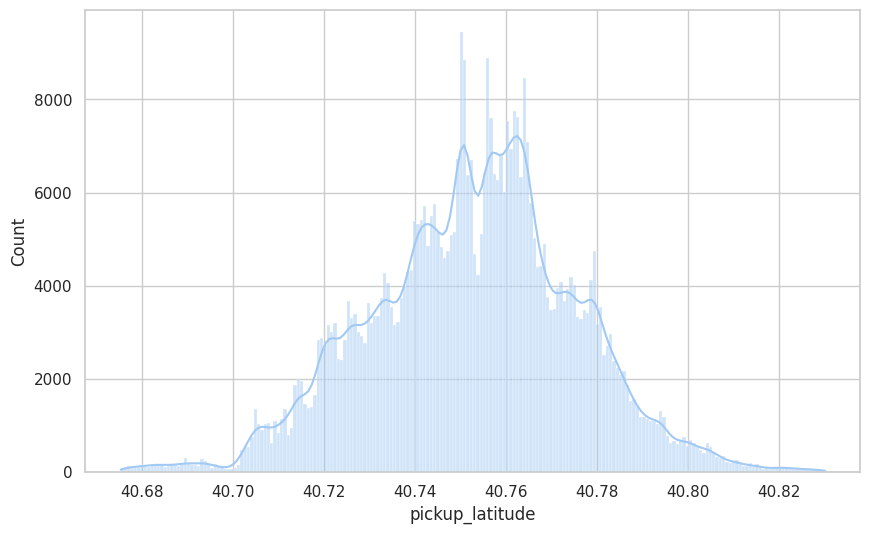

In [ ]:
sns.histplot(data=nyc_pickup_data['pickup_latitude'], kde=True)

<Axes: xlabel='pickup_longitude', ylabel='Count'>

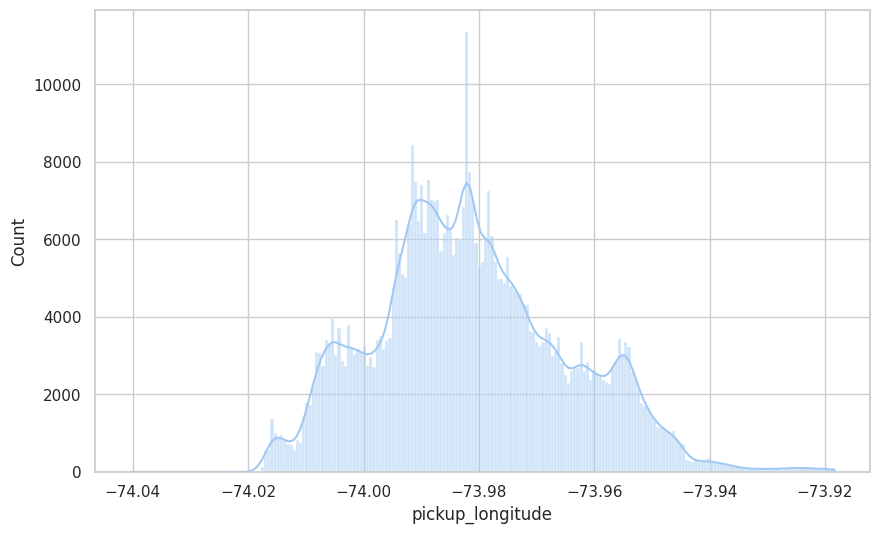

In [ ]:
sns.histplot(data=nyc_pickup_data['pickup_longitude'], kde=True)

<Axes: xlabel='dropoff_longitude', ylabel='Count'>

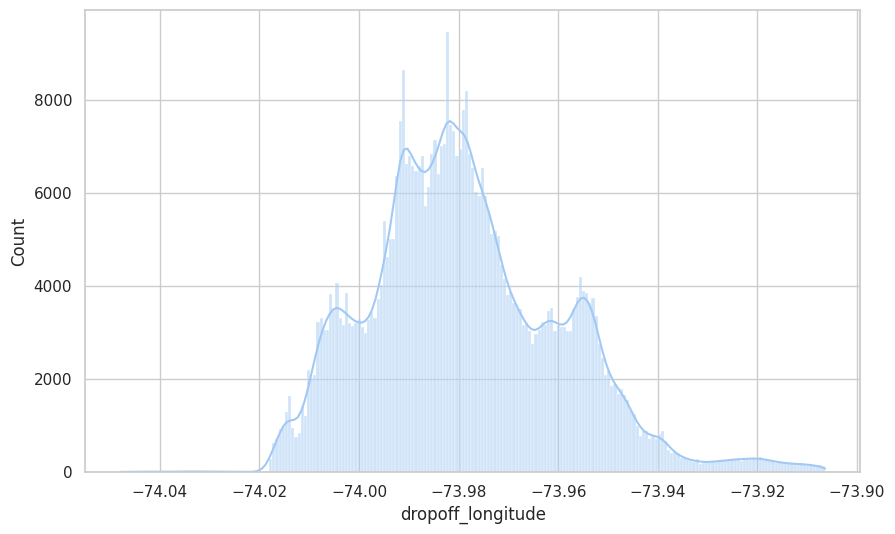

In [ ]:
sns.histplot(data=nyc_dropoff_data['dropoff_longitude'], kde=True)

<Axes: xlabel='dropoff_latitude', ylabel='Count'>

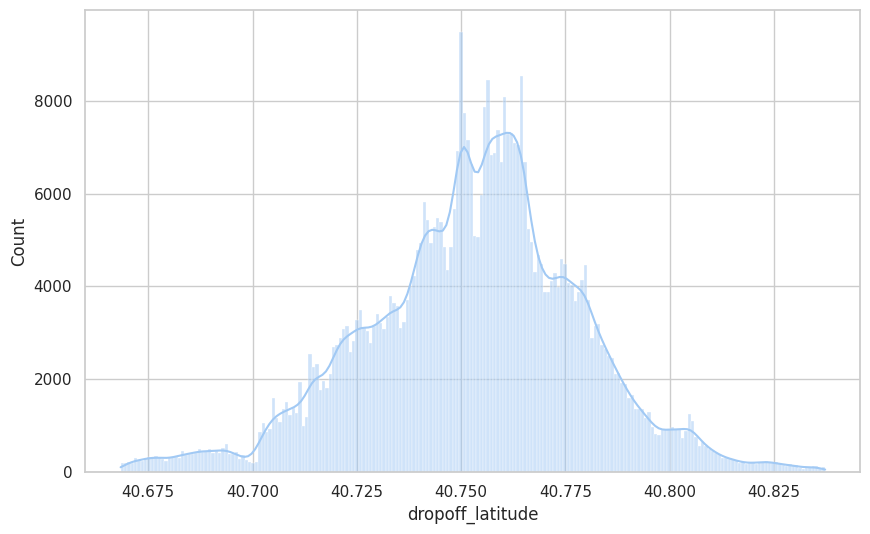

In [ ]:
sns.histplot(data=nyc_dropoff_data['dropoff_latitude'], kde=True)

Since this distribution looks good, let's go ahead and apply this capping on our main dataset

In [ ]:
nyc_data=nyc_data[((nyc_data.pickup_longitude>=lower_limit_lng) & (nyc_data.pickup_longitude<=upper_limit_lng))]
nyc_data=nyc_data[((nyc_data.pickup_latitude>=lower_limit_lat) & (nyc_data.pickup_latitude<=upper_limit_lat))]

nyc_data=nyc_data[((nyc_data.dropoff_longitude>=lower_limit_dlng) & (nyc_data.dropoff_longitude<=upper_limit_dlng))]
nyc_data=nyc_data[((nyc_data.dropoff_latitude>=lower_limit_dlat) & (nyc_data.dropoff_latitude<=upper_limit_dlat))]

In [ ]:
# !pip install contextily

In [ ]:
# @title
# !pip install geopandas


# import contextily as cx
# from contextily.tile import warp_img_transform, warp_tiles, _warper
# shp = gpd.read_file('tl_2020_36_place.shp')
# nyc = shp[shp.NAME=='New York']

la=list(nyc_pickup_data['pickup_latitude'])
lo=list(nyc_pickup_data['pickup_longitude'])

la_min=nyc_pickup_data['pickup_latitude'].min()
la_max=nyc_pickup_data['pickup_latitude'].max()

lo_min=nyc_pickup_data['pickup_longitude'].min()
lo_max=nyc_pickup_data['pickup_longitude'].max()


geometry = [Point(xy) for xy in zip(lo,la)]



In [ ]:
world_data=gpd.read_file(gpd.datasets.get_path('nybb')).to_crs('epsg:4326')
geo_df=gpd.GeoDataFrame(nyc_pickup_data[['pickup_longitude','pickup_latitude']],geometry=geometry,crs='epsg:4326')

<ipython-input-88-11142a9901fd>:1: FutureWarning:

The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'nybb' data from the geodatasets package.

from geodatasets import get_path
path_to_file = get_path('nybb')




<Axes: >

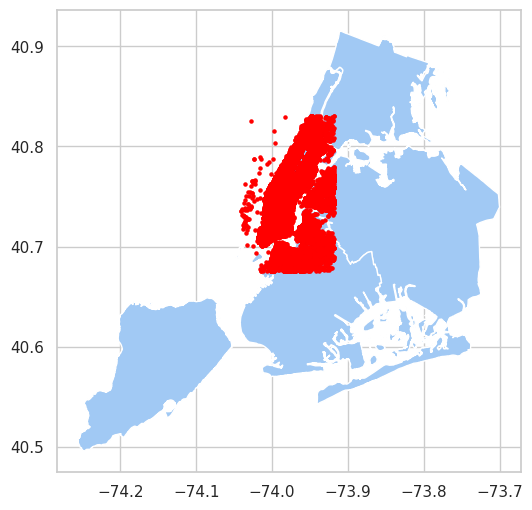

In [ ]:
ax=world_data.plot()
geo_df.plot(ax=ax, markersize=5, color='red')

In [ ]:
import folium

In [ ]:
m=folium.Map(location=[40.767937,-73.982155 ],tiles='OpenStreetMap',
 zoom_start=12,
 width="%100",
height="%100"
)
for row in nyc_pickup_data[:1000].iterrows():
    folium.CircleMarker([row[1]['pickup_latitude'],row[1]['pickup_longitude']], radius=2,fill_color='#FD8A6C').add_to(m)
m


In [ ]:
nyc_data.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'log_trip_duration', 'WeekDay', 'Month', 'hour',
       'pickup_date', 'Weekday_cat'],
      dtype='object')

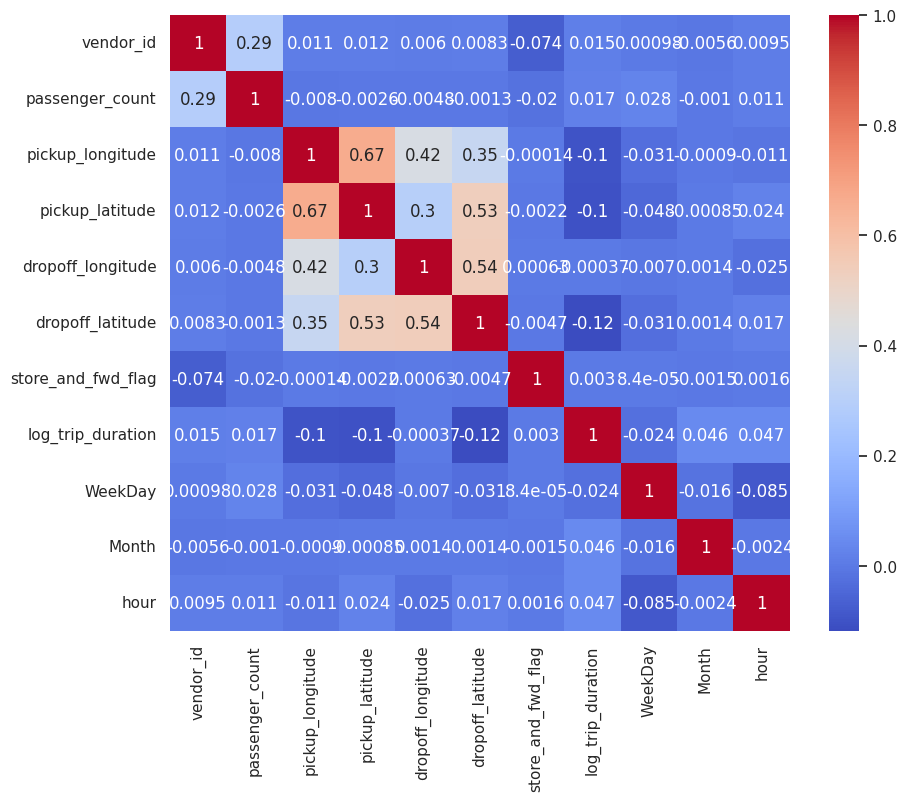

In [ ]:
correlation_matrix = nyc_data[['vendor_id',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'log_trip_duration', 'WeekDay', 'Month', 'hour',
      ]].corr()

# Create the heatmap
plt.figure(figsize = (10,8))
sns.heatmap(correlation_matrix, cmap = 'coolwarm', annot=True)
plt.show()

In [ ]:
# nyc_data.drop(columns=['vendor_id','store_and_fwd_flag','trip_duration','passenger_count','pickup_datetime','dropoff_datetime'], inplace=True)

Summary of the EDA done:-

